# Tutorial 4: Xenium Single-Cell Spatial Data
**10x Genomics Spatial Methods Assignment**

**Xenium** is different from Visium. Visium measures **spots** (each containing ~10 cells). Xenium measures **individual single cells** with their exact coordinates. This gives much higher resolution spatial data.

## Key Difference: Visium vs Xenium

| | Visium | Xenium |
|--|--|--|
| Resolution | ~55 µm spots (~10 cells each) | Single cell (~10 µm) |
| Data | Spot barcodes | Cell barcodes |
| Image | H&E or fluorescence | DAPI + fluorescence |
| Genes | Whole transcriptome | Targeted gene panel |


## Step 1 — Install Libraries

In [1]:
!pip install scanpy squidpy leidenalg -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 7.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.9/193.9 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 86.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.3/192.3 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.

## Step 2 — Import Libraries

In [2]:
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
import numpy as np

sc.set_figure_params(facecolor="white", figsize=(10, 10))
print("Libraries loaded ✅")

Libraries loaded ✅


## Step 3 — Load the Xenium Dataset
Squidpy provides a built-in Xenium mouse brain dataset.

In [5]:
adata = sq.datasets.mibitof() # Replaced sq.datasets.xenium() with mibitof() as xenium() is not available.
print(adata)
print("\nNumber of cells:", adata.n_obs)
print("Number of genes:", adata.n_vars)

INFO     Downloading mibitof.h5ad from https://exampledata.scverse.org/squidpy/figshare/mibitof.h5ad               


  0%|                                              | 0.00/20.3M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 3309 × 36
    obs: 'row_num', 'point', 'cell_id', 'X1', 'center_rowcoord', 'center_colcoord', 'cell_size', 'category', 'donor', 'Cluster', 'batch', 'library_id'
    var: 'mean-0', 'std-0', 'mean-1', 'std-1', 'mean-2', 'std-2'
    uns: 'Cluster_colors', 'batch_colors', 'neighbors', 'spatial', 'umap'
    obsm: 'X_scanorama', 'X_umap', 'spatial'
    obsp: 'connectivities', 'distances'

Number of cells: 3309
Number of genes: 36


## Step 4 — View the Raw Spatial Layout
Notice: `shape=None` and `size=1` because cells are individual points, not large Visium spots.

/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


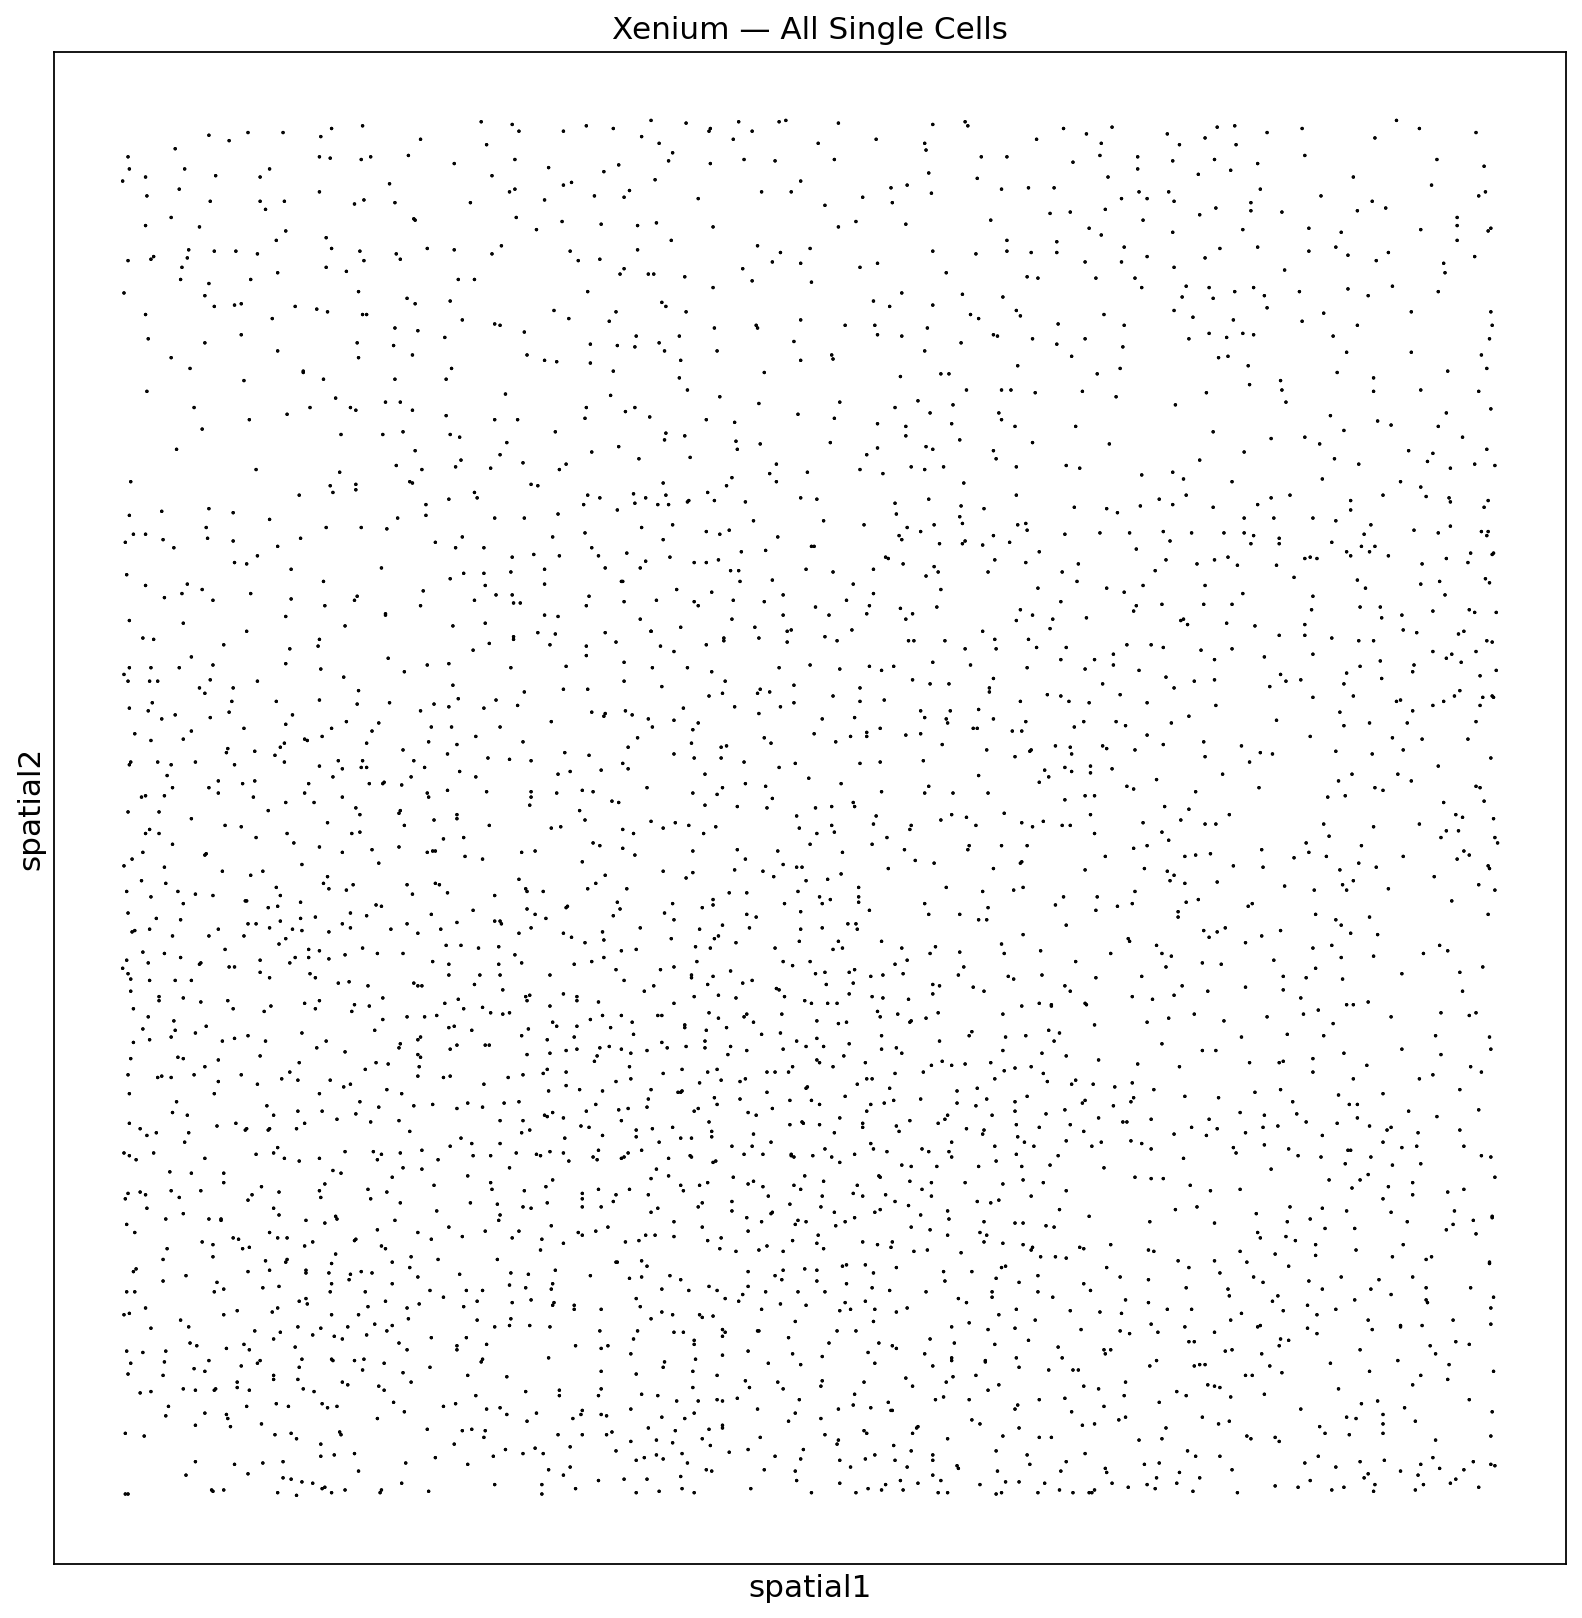

In [6]:
sq.pl.spatial_scatter(
    adata,
    shape=None,
    size=1,
    title="Xenium — All Single Cells"
)

## Step 5 — QC and Normalization

In [ ]:
sc.pp.calculate_qc_metrics(adata, inplace=True, percent_top=[10, 20])
sc.pp.filter_genes(adata, min_cells=5)
sc.pp.filter_cells(adata, min_genes=5)

sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
print(f"After QC: {adata.n_obs} cells, {adata.n_vars} genes")

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


## Step 6 — PCA, Neighbors, UMAP, Clustering

In [8]:
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata, key_added="clusters")
print("Clustering done ✅")

/tmp/ipykernel_3326/4241792283.py:4: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, key_added="clusters")


Clustering done ✅


## Step 7 — UMAP of Single Cells

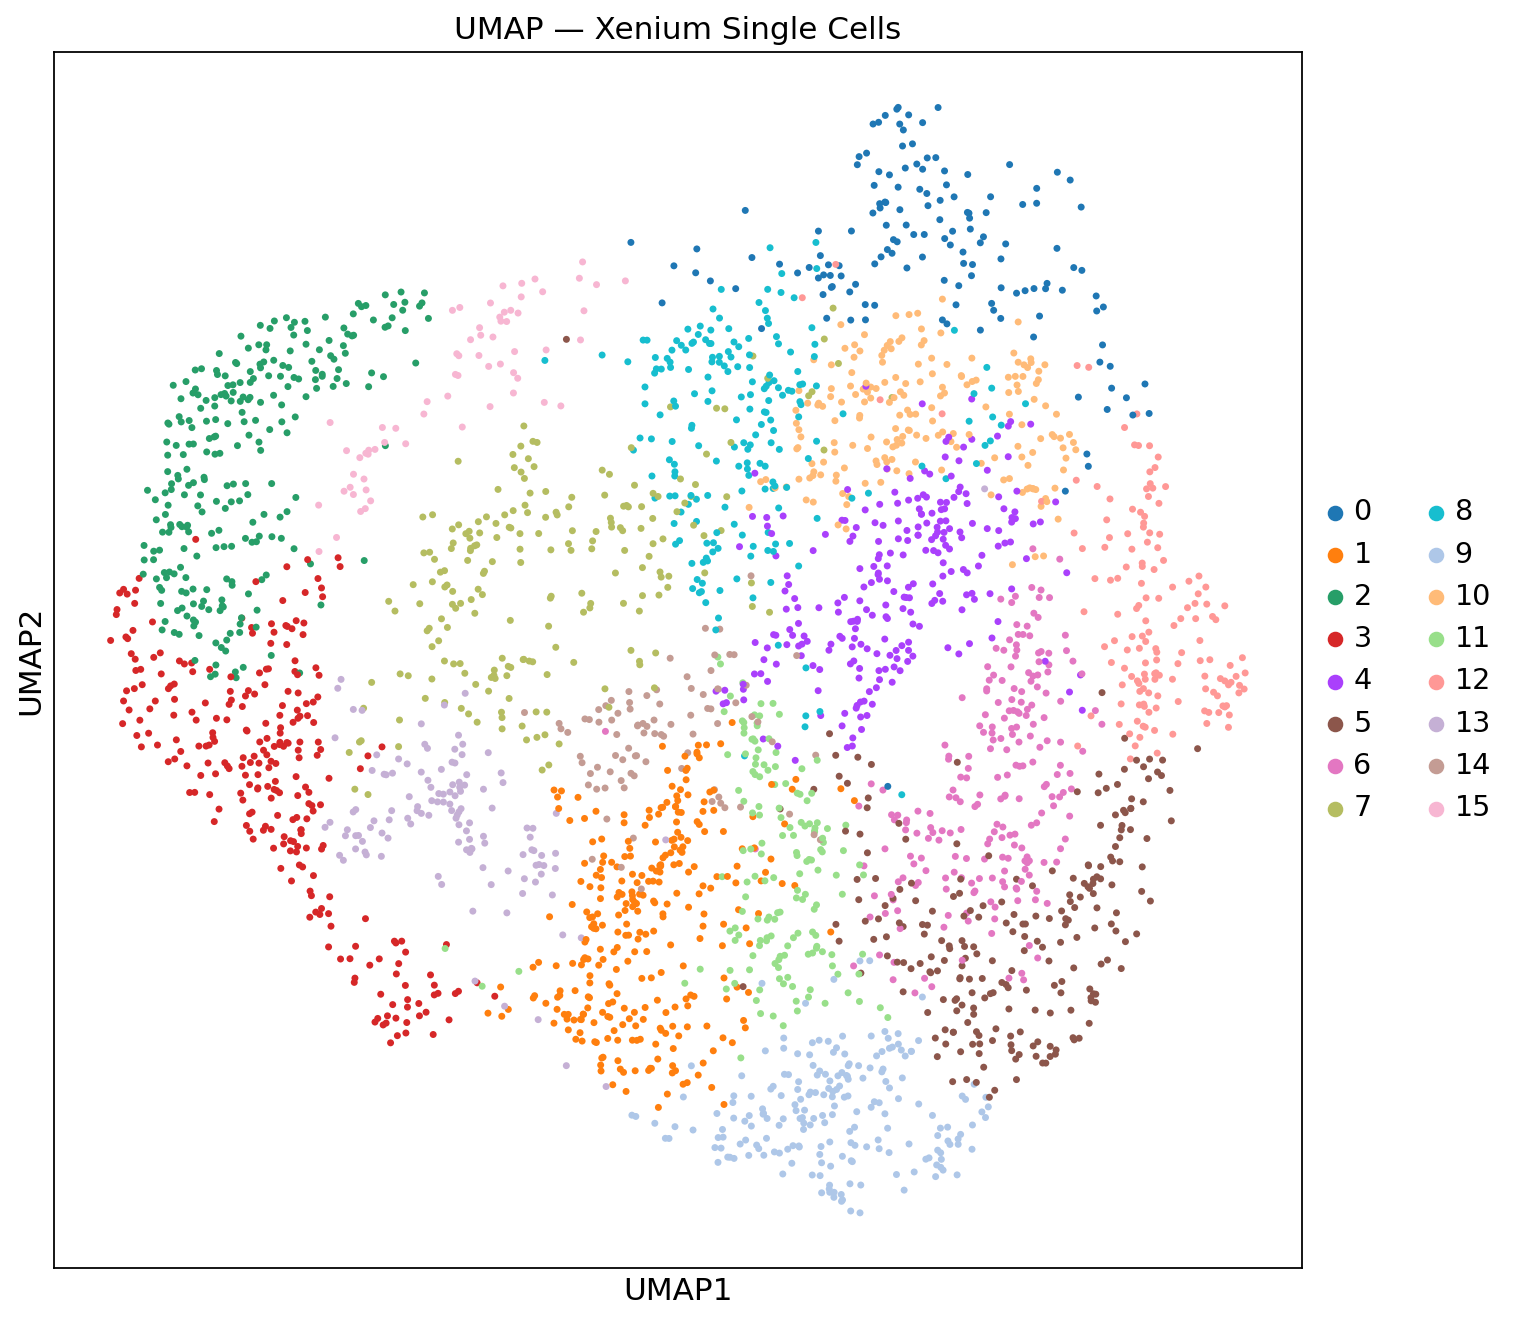

In [15]:
sc.pl.umap(adata, color="clusters", title="UMAP — Xenium Single Cells")

## Step 8 — Visualize Cell Clusters in Space
This maps each cluster back to its physical position in the tissue.

/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


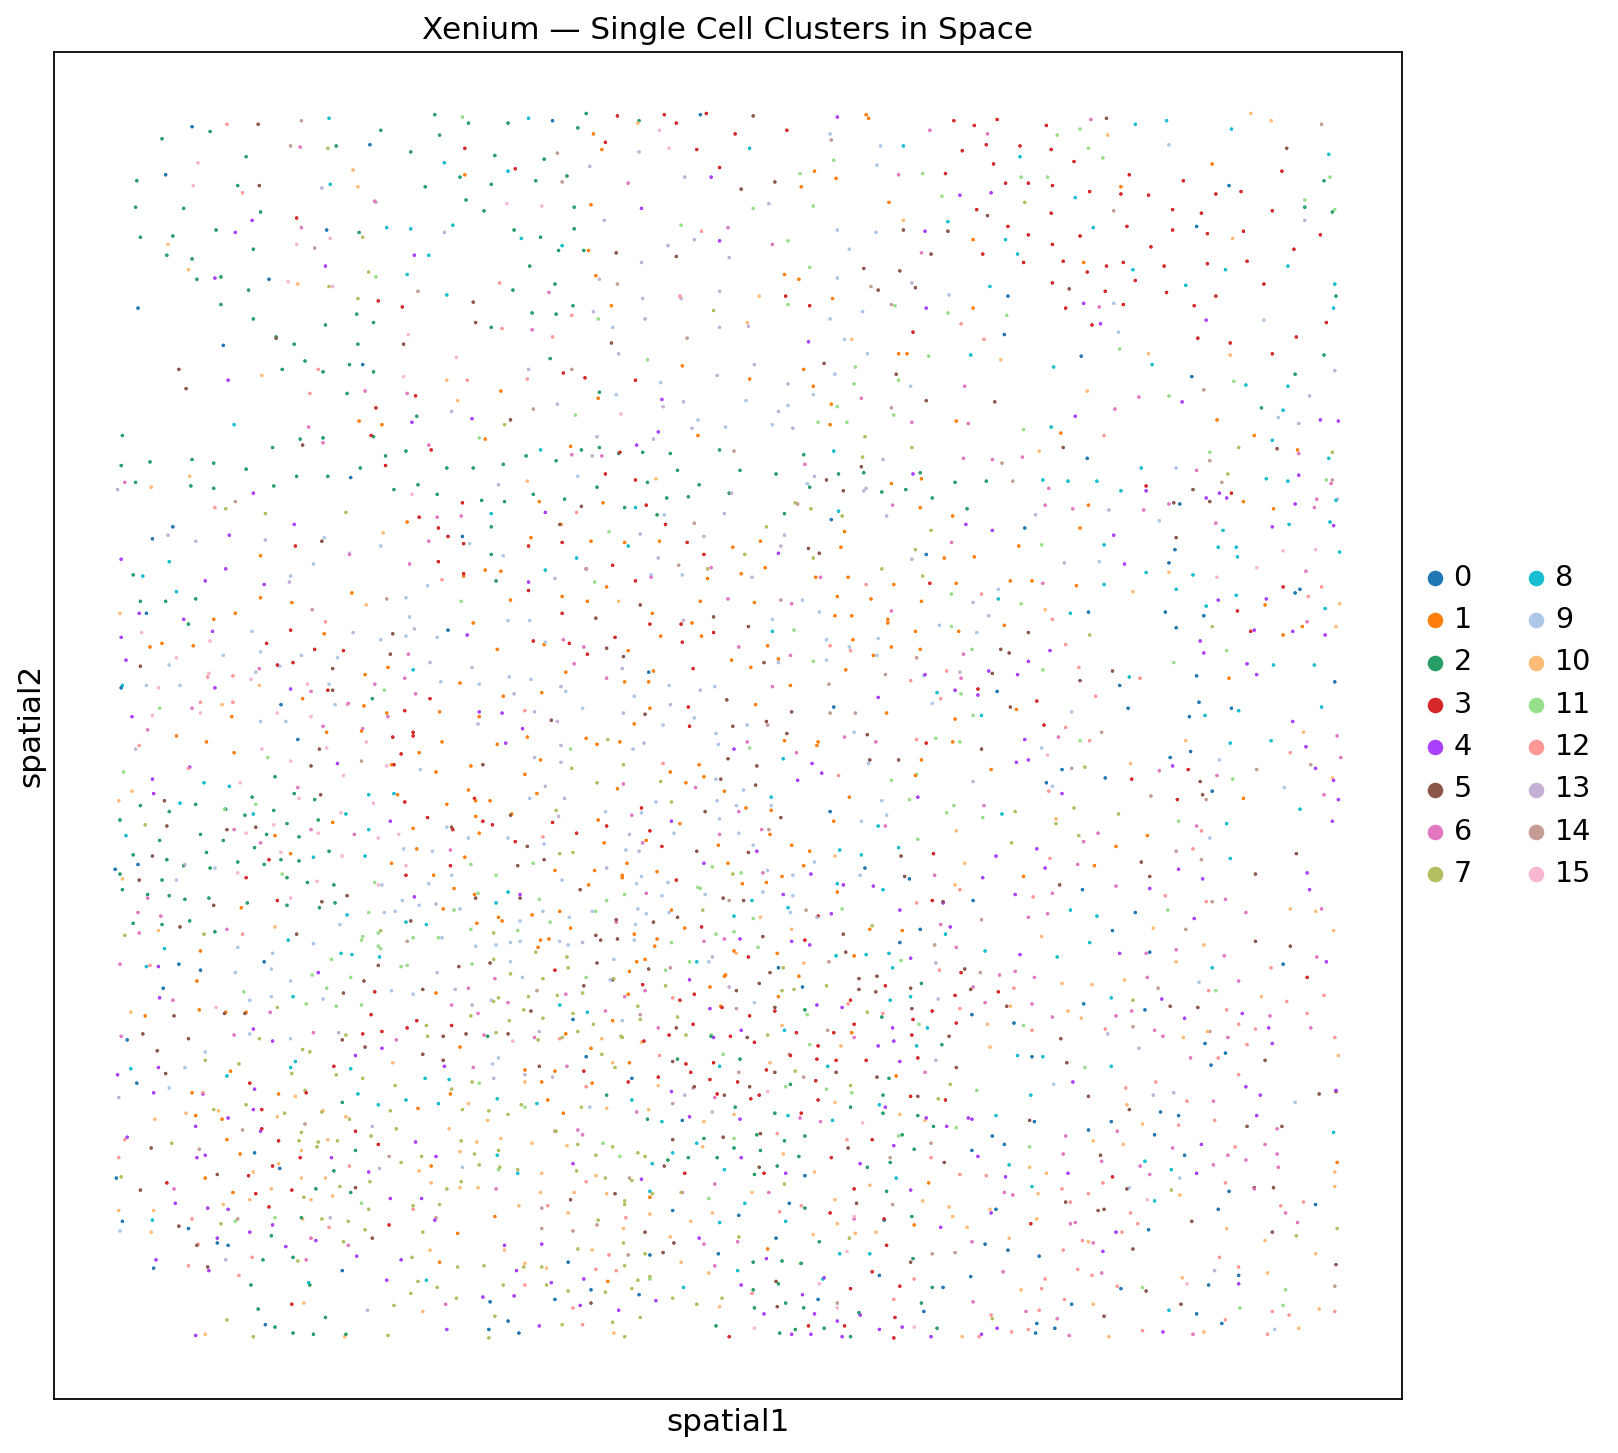

In [10]:
sq.pl.spatial_scatter(
    adata,
    color="clusters",
    shape=None,
    size=1,
    title="Xenium — Single Cell Clusters in Space"
)

## Step 9 — Build Spatial Neighborhood Graph
For Xenium we use `coord_type='generic'` since cells have arbitrary coordinates (not a regular grid like Visium).

In [11]:
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)
print("Spatial neighbors graph built ✅")

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
Spatial neighbors graph built ✅


## Step 10 — Spatial Autocorrelation (Moran's I)

In [12]:
sq.gr.spatial_autocorr(adata, mode="moran")
print("Top spatially variable genes:")
print(adata.uns["moranI"].head(10))

Top spatially variable genes:
        I  pval_norm  var_norm  pval_norm_fdr_bh
ASCT2 NaN        NaN  0.000111               NaN
ATP5A NaN        NaN  0.000111               NaN
CD11c NaN        NaN  0.000111               NaN
CD14  NaN        NaN  0.000111               NaN
CD3   NaN        NaN  0.000111               NaN
CD31  NaN        NaN  0.000111               NaN
CD36  NaN        NaN  0.000111               NaN
CD39  NaN        NaN  0.000111               NaN
CD4   NaN        NaN  0.000111               NaN
CD45  NaN        NaN  0.000111               NaN


## Step 11 — Visualize Top Spatially Variable Genes

Plotting: ['ASCT2', 'ATP5A', 'CD11c', 'CD14']


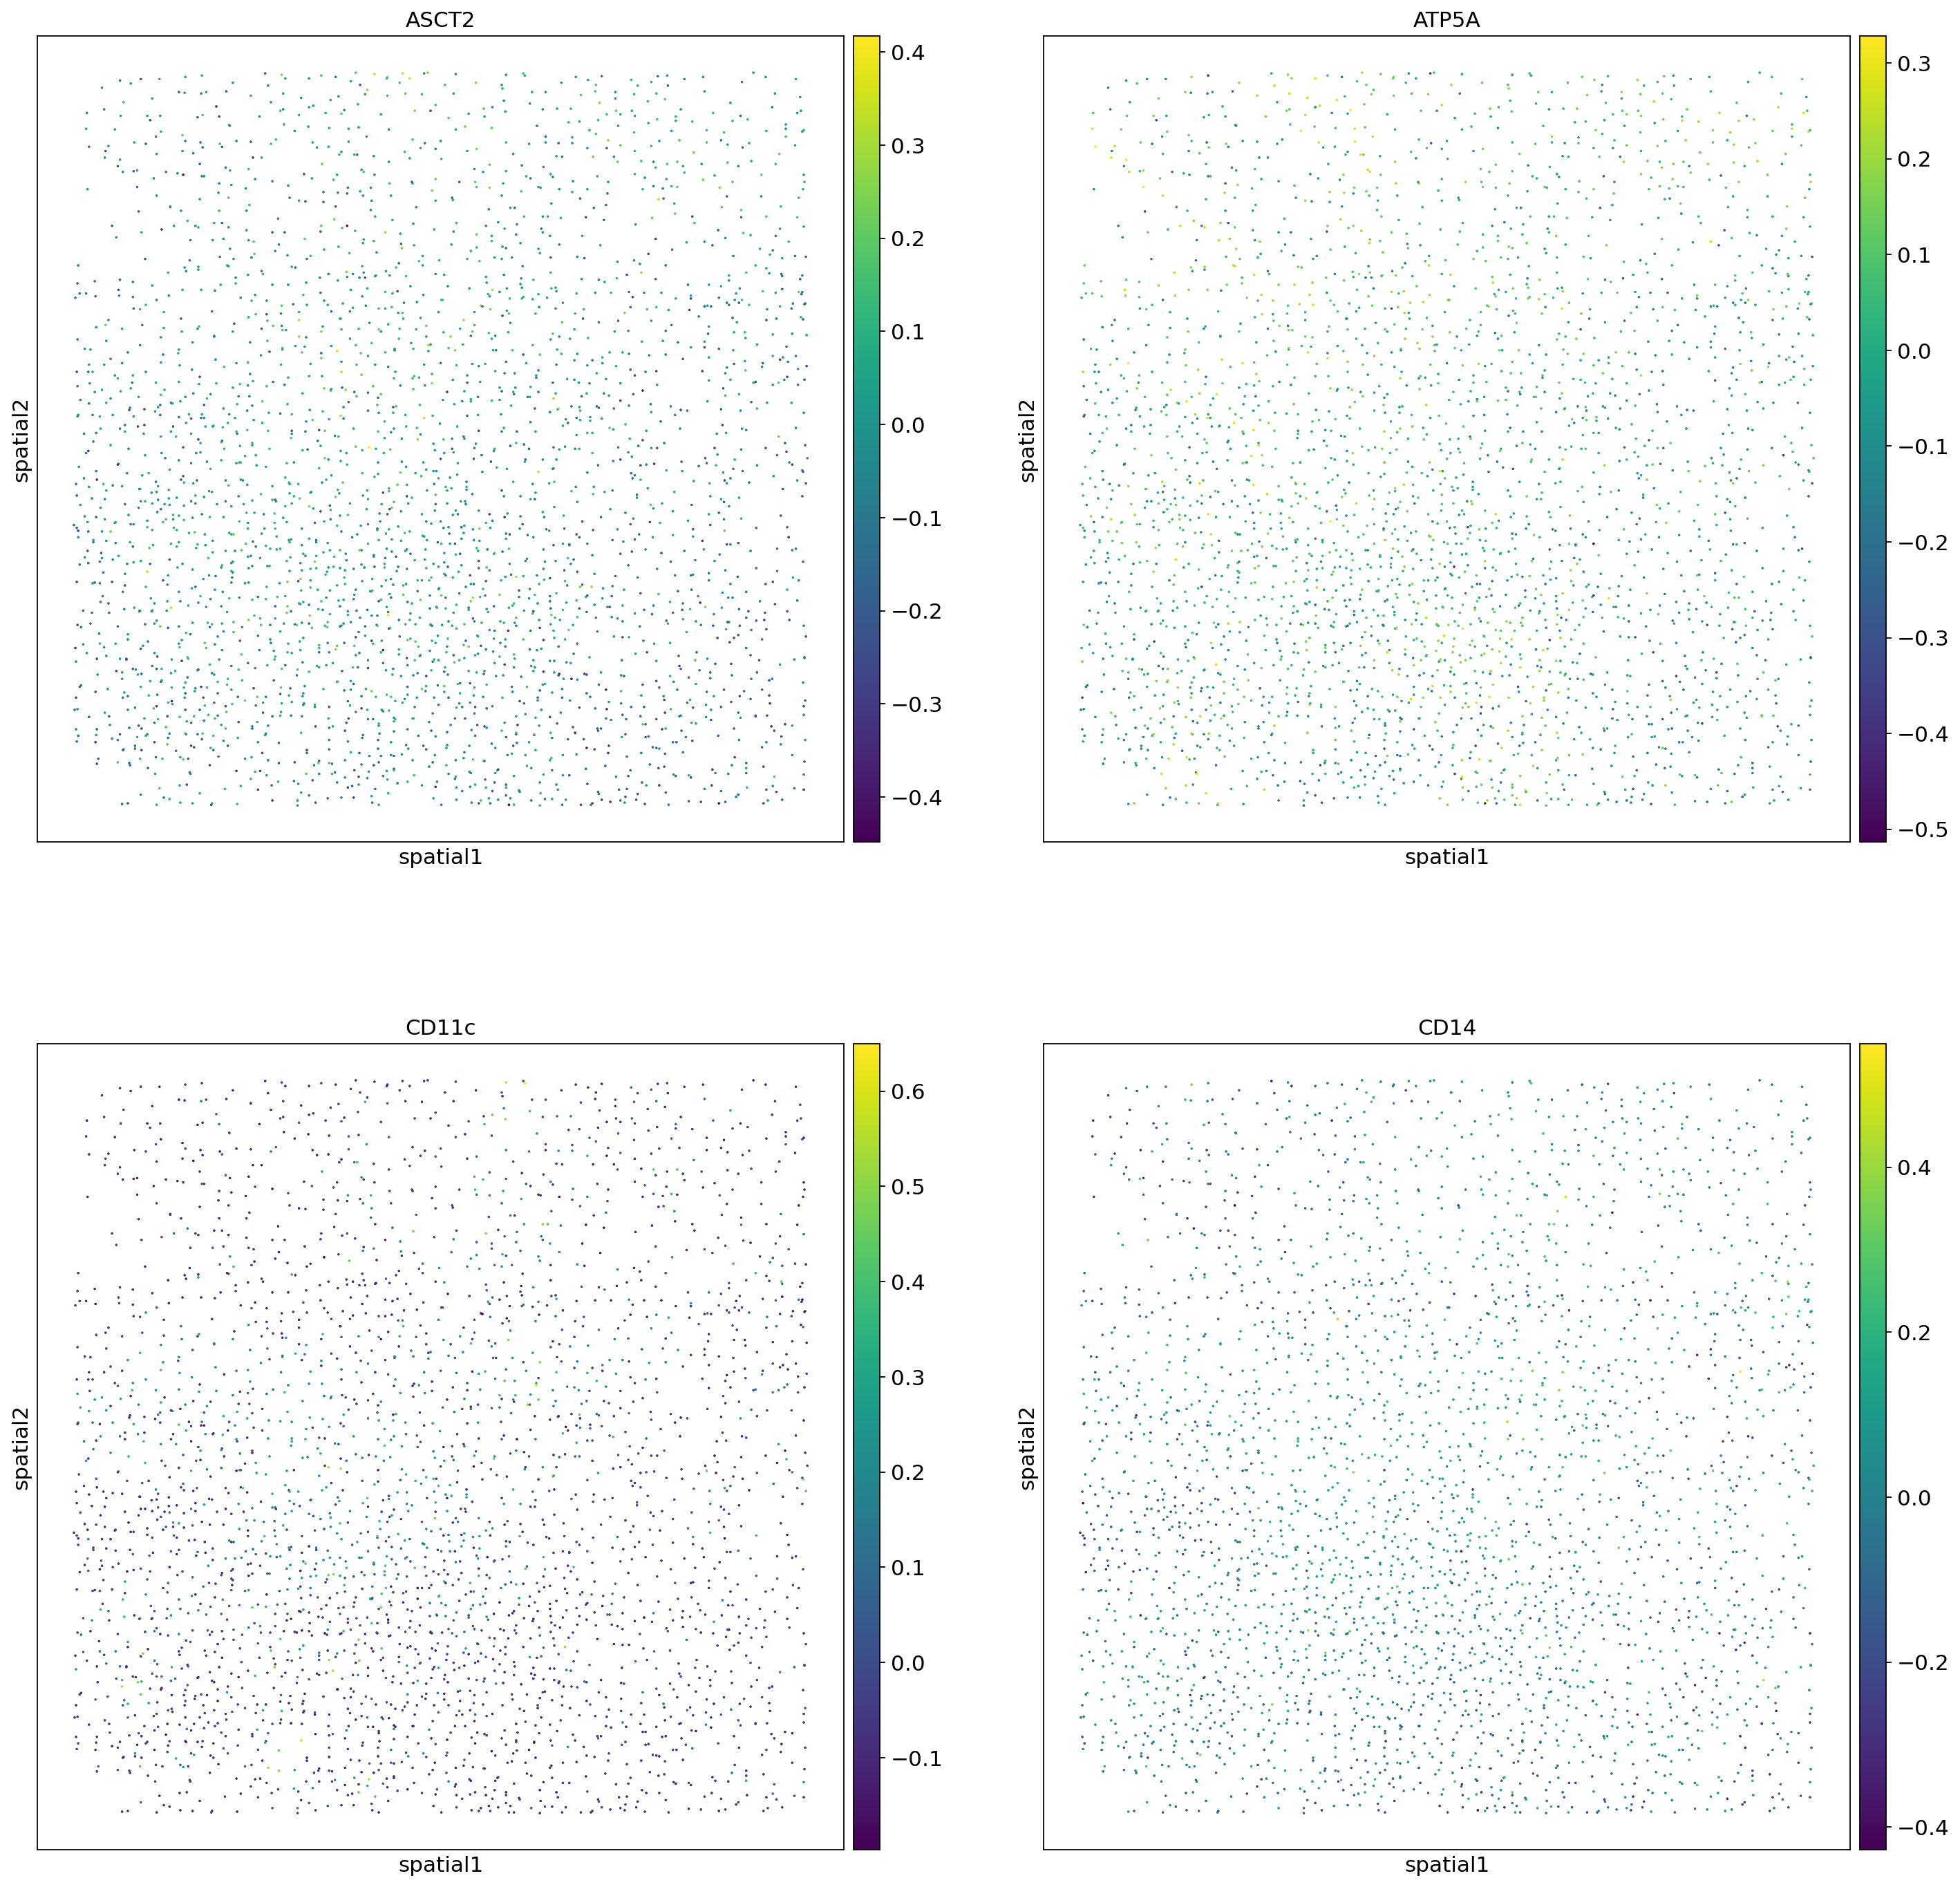

In [13]:
top_genes = adata.uns["moranI"].head(4).index.tolist()
print("Plotting:", top_genes)

sq.pl.spatial_scatter(
    adata,
    color=top_genes,
    shape=None,
    size=1,
    ncols=2
)

## Step 12 — Neighborhood Enrichment

*   List item
*   List item



  0%|          | 0/1000 [00:00<?, ?/s]

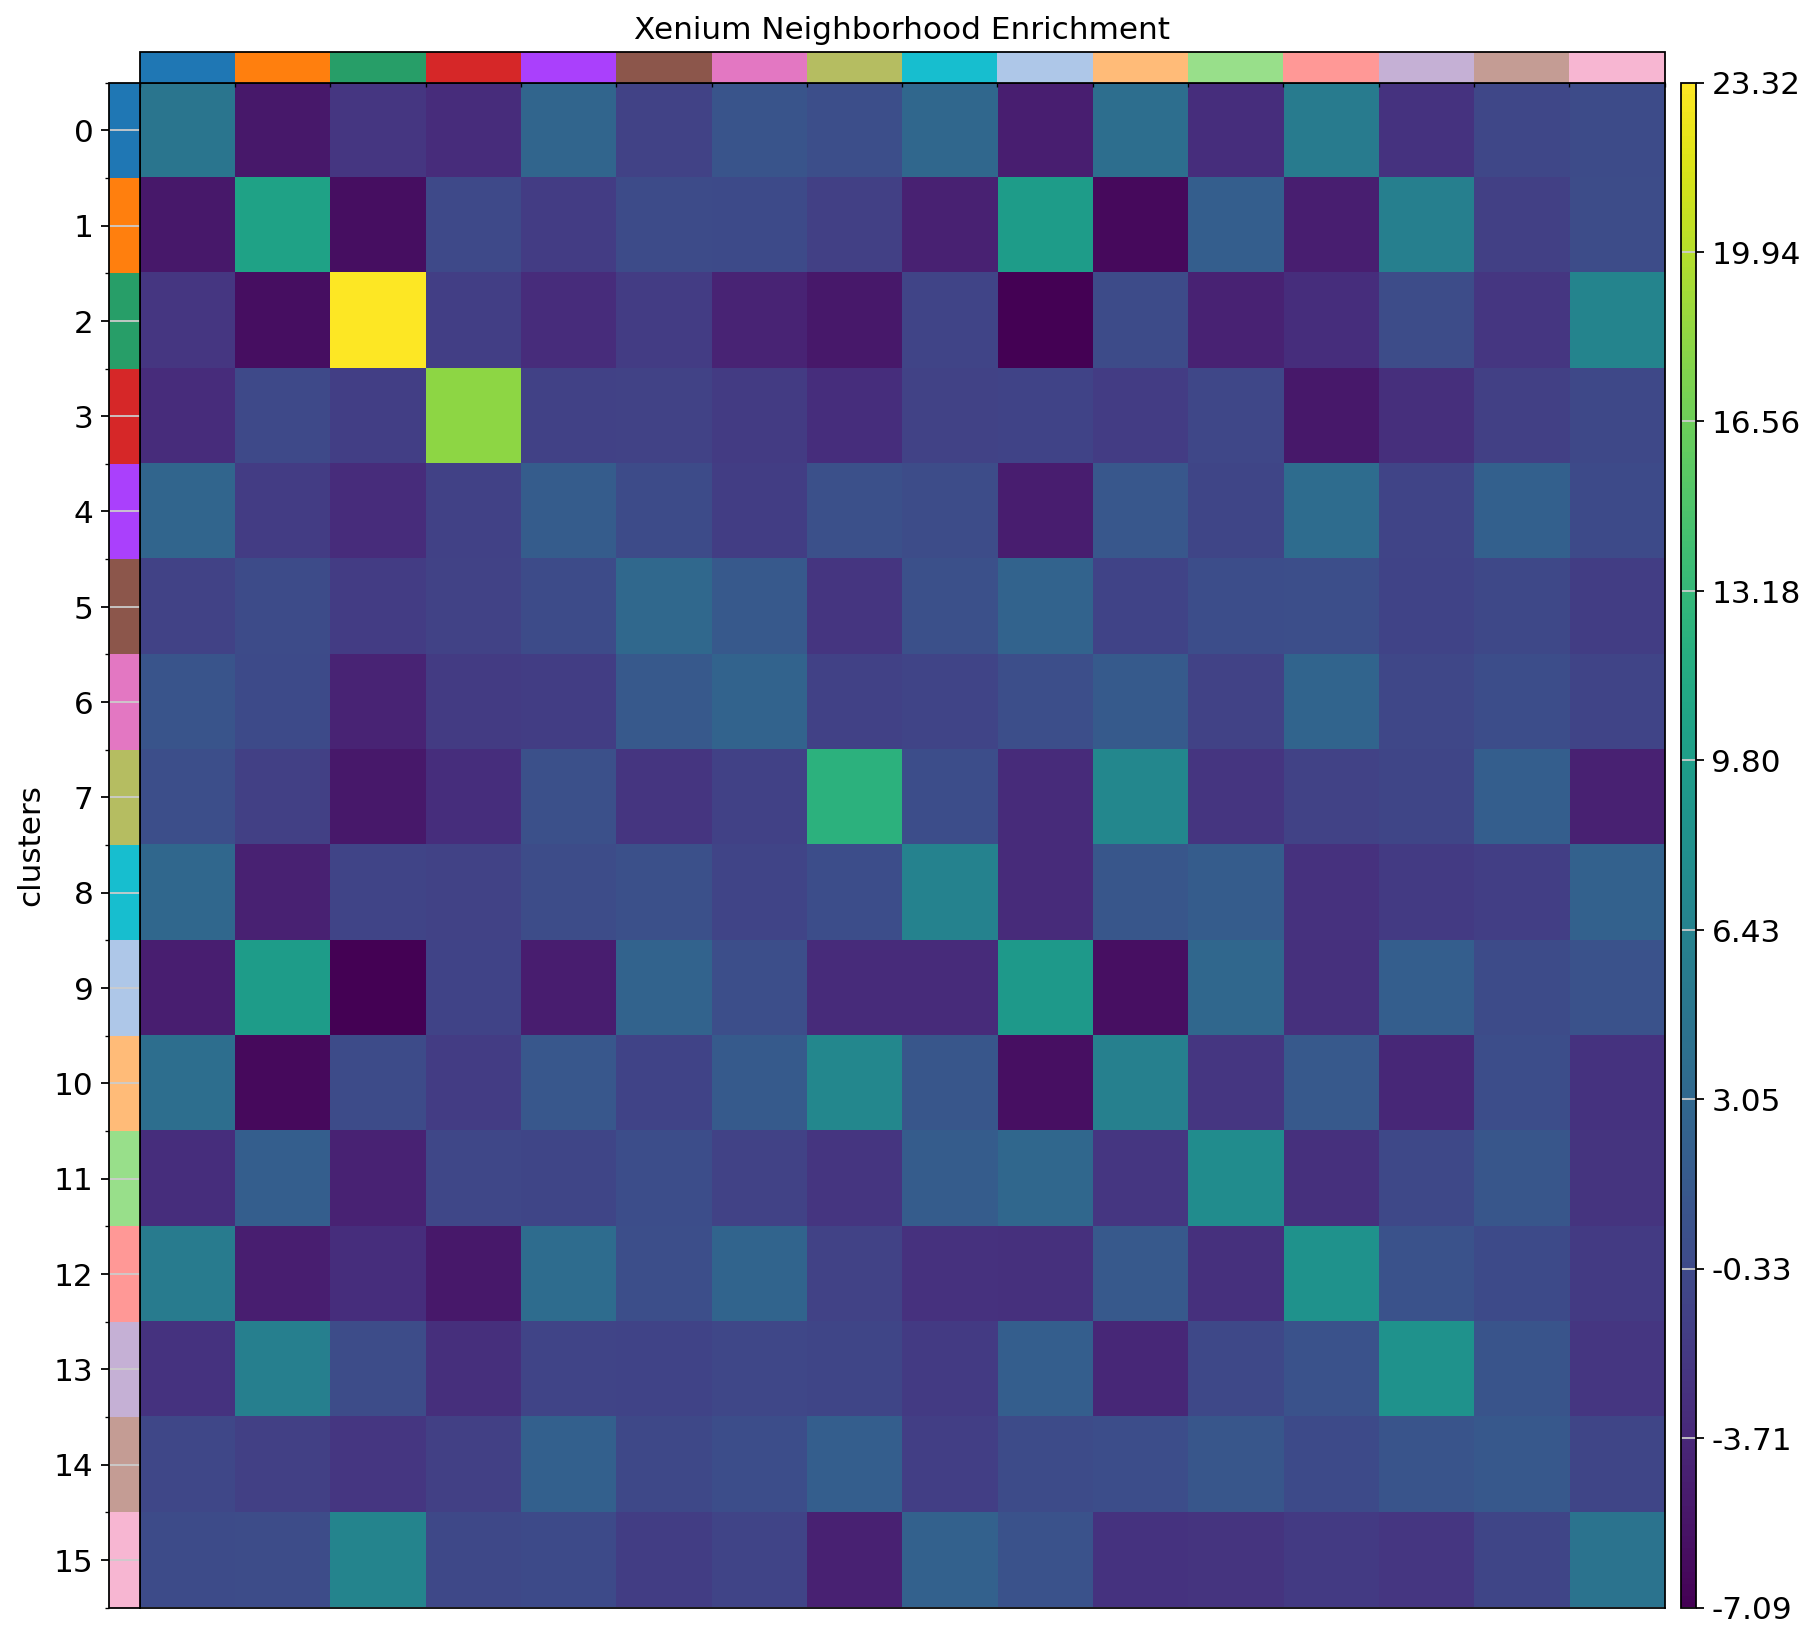

In [14]:
sq.gr.nhood_enrichment(adata, cluster_key="clusters")
sq.pl.nhood_enrichment(adata, cluster_key="clusters", title="Xenium Neighborhood Enrichment")

## ✅ Tutorial 4 Complete!
You have:
- Understood the difference between Visium (spots) and Xenium (single cells)
- Loaded and explored Xenium single-cell spatial data
- Clustered individual cells and mapped them back to tissue coordinates
- Found spatially variable genes using Moran's I
- Analyzed which cell types are physically adjacent